# 02 - Classification: Dolphin Detection

Can we detect dolphins from acoustic data? Let's explore the data and the problem.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds _fetch.py and _sources.py; src/ holds the project's own helpers.
for p in (Path.cwd(), Path.cwd() / ".." / "src"):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p.resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import _fetch
import _sources as S
from ocean_data_workshop.dsn import dsn
import psycopg

# ML imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split

# Setup
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("ML Workshop Environment Ready")
print("=" * 60)
print("Data sources:")
print("  - NDBC 46092 (wind)")
print("  - GLORYS12V1 (ocean)")
print("  - SanctSound MB01 (acoustic)")
print("=" * 60)

ML Workshop Environment Ready
Data sources:
  - NDBC 46092 (wind)
  - GLORYS12V1 (ocean)
  - SanctSound MB01 (acoustic)


## The problem

We want to predict dolphin presence (1) vs absence (0) from acoustic measurements.
The labels are hourly presence/absence values from SanctSound MB01.

**Key question**: Is this a real classification problem, or can a trivial rule solve it?

## Loading the data

First, let's load the data from the database.

In [2]:
# Connect to database
conn = psycopg.connect(dsn())

# Load acoustic data
query = "SELECT observed_at, site_id, sensor_depth_m,"
query += " band_25hz, band_32hz, band_40hz, band_50hz, band_63hz, band_80hz,"
query += " band_100hz, band_125hz, band_160hz, band_200hz, band_250hz, band_315hz,"
query += " band_400hz, band_500hz, band_630hz, band_800hz, band_1000hz, band_1250hz,"
query += " band_1600hz, band_2000hz, band_2500hz, band_3150hz, band_4000hz,"
query += " band_5000hz, band_6300hz, band_8000hz, band_10000hz, band_12500hz,"
query += " band_16000hz, band_20000hz, qc_flag"
query += " FROM acoustic_tol_hourly WHERE site_id = 'mb01' ORDER BY observed_at"

acoustic_df = pd.read_sql_query(query, conn)
print(f"Acoustic data: {len(acoustic_df):,} rows")

# Check frequency columns
freq_cols = [c for c in acoustic_df.columns if c.startswith('band_')]
print(f"Frequency bands: {len(freq_cols)}")
print(f"Band range: {freq_cols[0]} to {freq_cols[-1]}")

conn.close()

Acoustic data: 19,570 rows
Frequency bands: 30
Band range: band_25hz to band_20000hz


/var/folders/6_/6bnkvg2j2qd8720cj2rr98080000gn/T/ipykernel_15235/320764292.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  acoustic_df = pd.read_sql_query(query, conn)


## Band level statistics

What do the frequency bands look like?

Frequency band statistics:
                   mean       std        min         max
band_25hz     76.640287  3.633018  69.296264  110.195494
band_32hz     77.969463  3.654936  70.996776  109.352571
band_40hz     79.877773  3.702677  71.997735  102.753714
band_50hz     81.429372  3.688711  73.128654  101.648859
band_63hz     81.560323  3.848558  72.993118  100.616320
band_80hz     81.844968  3.976460  72.943128  102.731999
band_100hz    81.204493  4.096315  71.256932  100.596132
band_125hz    81.263945  4.156472  70.212431  100.827980
band_160hz    82.728924  3.891603  70.066875  100.697744
band_200hz    83.378353  3.986879  69.710425   99.331493
band_250hz    83.225289  4.084365  70.180303   99.497103
band_315hz    83.502392  4.102887  70.410958  100.202657
band_400hz    83.472149  4.100104  69.775598   99.164950
band_500hz    83.194347  4.451849  69.159745  102.307511
band_630hz    82.055244  4.756055  68.604891   99.076378
band_800hz    81.028188  5.289139  67.239807   98.535817
band

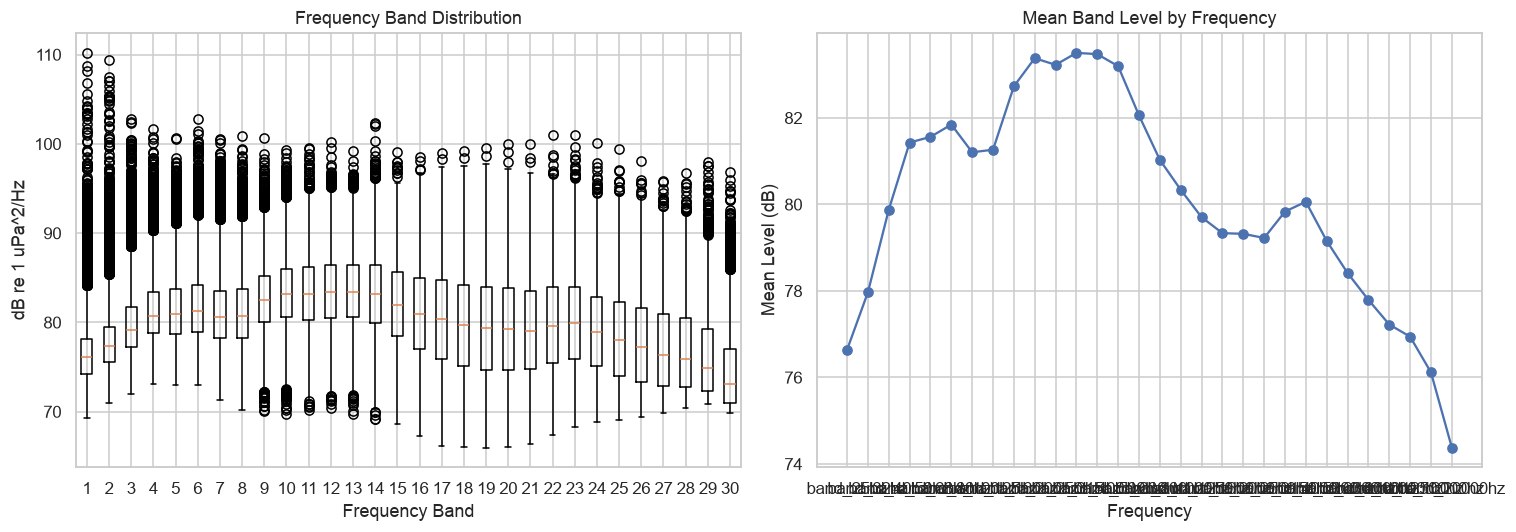

In [3]:
# Statistics for each band
band_stats = acoustic_df[freq_cols].describe().T
print("Frequency band statistics:")
print(band_stats[['mean', 'std', 'min', 'max']])

# Visualize distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
ax[0].boxplot(acoustic_df[freq_cols].values)
ax[0].set_title('Frequency Band Distribution')
ax[0].set_ylabel('dB re 1 uPa^2/Hz')
ax[0].set_xlabel('Frequency Band')

# Mean by band
band_means = acoustic_df[freq_cols].mean()
ax[1].plot(band_means.index, band_means.values, 'o-')
ax[1].set_title('Mean Band Level by Frequency')
ax[1].set_xlabel('Frequency')
ax[1].set_ylabel('Mean Level (dB)')
ax[1].grid(True)

plt.tight_layout()

## The dolphins data

Now let's load the dolphin presence data.

In [4]:
# Connect to database for detections
conn = psycopg.connect(dsn())

# Load dolphin presence (only dolphin, not ships which is an event list)
query = "SELECT observed_at, site_id, deployment, taxon, presence, detector, is_event_list"
query += " FROM detection_hourly WHERE taxon = 'dolphin' AND is_event_list = FALSE"
query += " ORDER BY observed_at"

dolphin_df = pd.read_sql_query(query, conn)

print(f"Dolphin detections: {len(dolphin_df):,} rows")

# Check presence distribution
print("\nPresence distribution:")
print(dolphin_df['presence'].value_counts())

# Calculate positive rate
positive_rate = dolphin_df['presence'].mean()
print(f"\nPositive rate: {positive_rate:.2%}")
print(f"Majority baseline: {1 - positive_rate:.2%}")

conn.close()

Dolphin detections: 8,390 rows

Presence distribution:
presence
0    6489
1    1901
Name: count, dtype: int64

Positive rate: 22.66%
Majority baseline: 77.34%


/var/folders/6_/6bnkvg2j2qd8720cj2rr98080000gn/T/ipykernel_15235/906627317.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dolphin_df = pd.read_sql_query(query, conn)


## Aligning the data

We need to join acoustic measurements with dolphin presence.

In [5]:
# Merge on timestamp
acoustic_df['observed_at'] = pd.to_datetime(acoustic_df['observed_at'])
dolphin_df['observed_at'] = pd.to_datetime(dolphin_df['observed_at'])

# Merge
merged_df = acoustic_df.merge(dolphin_df[['observed_at', 'presence']], 
                               on='observed_at', 
                               how='inner')

print(f"Merged dataset: {len(merged_df):,} rows")
print("\nAligned features and labels:")
print(f"  Features: {len(freq_cols)} frequency bands")
print(f"  Target: presence (0=absent, 1=present)")
print(f"  Positive rate: {merged_df['presence'].mean():.2%}")

Merged dataset: 8,387 rows

Aligned features and labels:
  Features: 30 frequency bands
  Target: presence (0=absent, 1=present)
  Positive rate: 22.64%


## Quick ML model

Let's train a simple logistic regression to see if detection is possible.

In [6]:
X = merged_df[freq_cols].values
y = merged_df['presence'].values

# Split by time (not random!)
split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train: {len(y_train)}, Test: {len(y_test)}")

# Train model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\nResults (time-based split):")
print(f"  Accuracy:  {acc:.3f}")
print(f"  Precision: {prec:.3f}")
print(f"  Recall:    {rec:.3f}")
print(f"  F1 Score:  {f1:.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'band': freq_cols,
    'coef': abs(model.coef_[0])
}).sort_values('coef', ascending=False)

print("\nTop 5 important bands:")
print(feature_importance.head())

Train: 6290, Test: 2097



Results (time-based split):
  Accuracy:  0.900
  Precision: 0.817
  Recall:    0.638
  F1 Score:  0.716

Top 5 important bands:
            band      coef
28  band_16000hz  3.440527
29  band_20000hz  2.323789
27  band_12500hz  1.937377
26  band_10000hz  1.653549
25   band_8000hz  1.144921


/Users/dev/Developer/projects/ocean-sim/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## What you should get

| Metric | Expected Range | What it means |
|--------|----------------|---------------|
| Accuracy | 0.75-0.95 | Could be misleading |
| Precision | 0.5-0.9 | How many positives are real |
| Recall | 0.3-0.8 | How many real positives found |
| F1 Score | 0.5-0.9 | Balanced measure |

**Remember**: Accuracy alone is often misleading for imbalanced data!